# 🌐 Moira Analytics: Análise de Risco Sistêmico e Contágio em FIIs (IFIX) via Teoria dos Grafos
**Metodologia:** CRISP-NET (Cross-Industry Standard Process for Network Analysis)  
**Objetivo:** Transpor a análise de indicadores financeiros estáticos para uma topologia dinâmica de redes, mapeando as interdependências ocultas do mercado imobiliário da B3, localizando os "Hubs" de risco e estabelecendo agrupamentos não-supervisionados de ativos.

<div align="center">
    <h3>🎓 Equipe de Pesquisa</h3>
    <b>Disciplina:</b> CMAC03 - Algoritmos em Grafos &nbsp;
    <br>
    &nbsp; <b>Professor:</b> Prof. Rafael Frinhani<br><br>
    <b>Ana Paula Gomes Jacó</b> [2025015633] &nbsp; •&nbsp; <b>Bianca Salvador</b> [2022012137]<br>
    <b>Isaac Davi Mendonça Viana</b> [2023000650] &nbsp;•&nbsp; <b>Laura Raimundi Dias Jesus</b> [2022002097]<br><br>
    <i>Universidade Federal de Itajubá (UNIFEI)</i>
    <br>

</div>
<br>

---
## 1. Setup e Bibliotecas

Para suportar o *framework*, orquestramos um conjunto de bibliotecas de ponta da linguagem Python, divididas em três pilares computacionais:

1. **Coleta e Engenharia de Dados (ETL):** Utilizaremos `yfinance` para extração de séries temporais financeiras em tempo real, aliada a `pandas` e `numpy` para o tratamento vetorial das cotações e cálculo da Matriz de Distâncias.
2. **Topologia e Física Estatística:** A biblioteca `networkx` será o motor matemático central, responsável por desenhar o PMFG (*Planar Maximally Filtered Graph*), calcular as centralidades matriciais (Risco) e executar os algoritmos heurísticos de comunidades (Machine Learning).
3. **Renderização Científica e Web:** `plotly` e `pyvis` serão empregados para exportar a geometria da rede em instâncias HTML interativas, enquanto `matplotlib` e `seaborn` apoiarão a geração de relatórios de benchmarking nos padrões exigidos para publicações acadêmicas.

In [1]:
# ========================================================
# 1. IMPORTAÇÃO DOS MOTORES MATEMÁTICOS E DE VISUALIZAÇÃO
# ========================================================
# Instalação das bibliotecas necessárias (descomente para rodar localmente a primeira vez)
# !pip install yfinance pandas numpy matplotlib seaborn networkx plotly scipy nbformat pyvis

import yfinance as yf
import pandas as pd
import numpy as np

import networkx as nx
import networkx.algorithms.community as nx_comm

import plotly.graph_objects as go
from pyvis.network import Network
import matplotlib.pyplot as plt
import seaborn as sns

import os
import time
import math
import itertools
import warnings
warnings.filterwarnings("ignore")

---

## 2. Data Understanding: O Universo de FIIs
Definimos um dicionário com os ativos mais relevantes do IFIX e extraímos a sua série histórica de cotações ajustadas da API do Yahoo Finance. A janela (2020 a 2025) foi escolhida para capturar o estresse máximo do mercado (Pandemia e Ciclo da Selic).

In [2]:
# Dicionário de Setores Mapeados Oficialmente pela B3
setores_reais = {
    'HGLG11.SA': 'Logística', 'BTLG11.SA': 'Logística', 'XPLG11.SA': 'Logística', 'VILG11.SA': 'Logística', 
    'MXRF11.SA': 'Papel', 'KNCR11.SA': 'Papel', 'IRDM11.SA': 'Papel', 'KNIP11.SA': 'Papel', 'HCTR11.SA': 'Papel', 
    'VISC11.SA': 'Shoppings', 'XPML11.SA': 'Shoppings', 'HGBS11.SA': 'Shoppings', 'HSML11.SA': 'Shoppings',
    'BRCR11.SA': 'Lajes Corp.', 'VINO11.SA': 'Lajes Corp.', 'HGRE11.SA': 'Lajes Corp.', 'PVBI11.SA': 'Lajes Corp.',
    'SDIL11.SA': 'Logística', 'HTMX11.SA': 'Renda Urbana', 'FIIB11.SA': 'Logística',
    'HGRU11.SA': 'Renda Urbana', 'TRXF11.SA': 'Renda Urbana', 'BBPO11.SA': 'Renda Urbana', 
    'RZTR11.SA': 'Fiagro', 'BTAL11.SA': 'Fiagro', 'BCRI11.SA': 'Papel', 'RBRR11.SA': 'Papel', 
    'MCCI11.SA': 'FoF', 'KFOF11.SA': 'FoF', 'HGFF11.SA': 'FoF','BRCO11.SA': 'Logística',
    'ALZR11.SA': 'Híbrido', 'TGAR11.SA': 'Desenvolvimento', 'BARI11.SA': 'Papel',
    'BCIA11.SA': 'FoF', 'CARE11.SA': 'Renda Urbana', 'CPTS11.SA': 'Papel', 'RECR11.SA': 'Papel',
    'CBOP11.SA': 'Lajes Corp.', 'CPFF11.SA': 'FoF', 'CXCE11.SA': 'Lajes Corp.', 'NVHO11.SA': 'Renda Urbana',
    'FLMA11.SA': 'Híbrido', 'FVPQ11.SA': 'Shoppings', 'GGRC11.SA': 'Logística', 'GTWR11.SA': 'Lajes Corp.',
    'HABT11.SA': 'Papel', 'HGCR11.SA': 'Papel', 'HGPO11.SA': 'Lajes Corp.', 'HPDP11.SA': 'Shoppings',
    'HRDF11.SA': 'Desenvolvimento', 'HUSC11.SA': 'Renda Urbana', 'LVBI11.SA': 'Logística', 
    'JSRE11.SA': 'Lajes Corp.', 'KNHY11.SA': 'Papel', 'KNRE11.SA': 'Desenvolvimento', 'KNRI11.SA': 'Híbrido',
    'MBRF11.SA': 'Renda Urbana', 'MFII11.SA': 'Desenvolvimento', 'NEWL11.SA': 'Logística',
    'OUJP11.SA': 'Papel', 'PABY11.SA': 'Híbrido', 'PATC11.SA': 'Lajes Corp.', 'PLCR11.SA': 'Papel',
    'PORD11.SA': 'Papel', 'PQDP11.SA': 'Shoppings', 'RBOP11.SA': 'Lajes Corp.', 'RBRF11.SA': 'FoF',
    'RBRP11.SA': 'Híbrido', 'RBRY11.SA': 'Papel', 'RBVA11.SA': 'Renda Urbana', 'FIGS11.SA': 'Shoppings',
    'RCFA11.SA': 'Híbrido', 'RCRB11.SA': 'Lajes Corp.', 'RECT11.SA': 'Lajes Corp.', 'RNDP11.SA': 'Papel',
    'RNGO11.SA': 'Lajes Corp.', 'SARE11.SA': 'Híbrido', 'SPTW11.SA': 'Lajes Corp.', 'VGIP11.SA': 'Papel',
    'VGIR11.SA': 'Papel', 'VRTA11.SA': 'Papel', 'XPIN11.SA': 'Logística', 'XPSF11.SA': 'FoF',
}

tickers_ifix = list(setores_reais.keys())

print("⏳ Baixando dados do Yahoo Finance...")
dados_brutos = yf.download(tickers_ifix, 
                           start = "2020-01-01", 
                           end = "2025-01-01", 
                           progress = False)['Close']
volumes_brutos = yf.download(tickers_ifix, 
                             start = "2020-01-01", 
                             end = "2025-01-01", 
                             progress = False)['Volume']

print(f"✅ Download Concluído! Extraídos {dados_brutos.shape[1]} ativos")

⏳ Baixando dados do Yahoo Finance...
✅ Download Concluído! Extraídos 84 ativos


---

## 3. Data Preparation: Filtros de Higienização
Para evitar "Regressões Espúrias" e conexões falsas (ruído matemático), precisamos varrer fundos mortos, recém-lançados ou severamente ilíquidos.
1. **Filtro Temporal:** Exige sobrevivência em pelo menos 75% dos pregões.
2. **Filtro de Liquidez:** Remove ativos cujo volume de negociação foi zero em muitos dias (o que causa estagnação de preço e falsas correlações).

### 3.1. Demonstração Didática: A Etapa de Transformação (KDD)

Para ilustrar de forma clara como os dados fluem da extração bruta até a modelagem matemática, isolamos um pequeno subconjunto de *tickers* didáticos. 

Na modelagem financeira, algoritmos de grafos e aprendizado de máquina não conseguem interpretar "preços nominais" de forma eficiente. O preço de uma cota não é uma série estacionária; ele embute vieses de inflação, desdobramentos e tendências de longo prazo. Para que os preceitos da **Econofísica** sejam aplicáveis, precisamos traduzir o valor nominal na verdadeira linguagem do risco: a **Variação**.

Nesta demonstração, o pipeline executa três validações:
1. **Visão dos Dados Brutos:** O espelho exato do fechamento do mercado (B3).
2. **Estatísticas Descritivas:** O mapeamento da volatilidade ($\sigma$) e dos limites transacionais de cada fundo.
3. **Retorno Logarítmico ($R_t$):** A transformação core do modelo, dada pela equação $R_t = \ln(P_t / P_{t-1})$. Esta conversão estabiliza a variância da série temporal, gerando os retornos contínuos que alimentarão a nossa Matriz de Distâncias Topológicas.
> Fórmula explicada por M. F. M. Osborne em seu artigo "Brownian Motion in the Stock Market" (publicado na revista Operations Research (Vol. 7, No. 2, pp. 145-173) 1959)

In [3]:
tickers_didaticos = ['HGLG11.SA', 'BTLG11.SA', 'XPLG11.SA', 'VILG11.SA',
                    'MXRF11.SA', 'KNCR11.SA', 'IRDM11.SA', 'KNIP11.SA', 
                    'VISC11.SA', 'XPML11.SA', 'HGBS11.SA', 'HSML11.SA',
                    'BRCR11.SA', 'VINO11.SA', 'HGRE11.SA','HCTR11.SA',
                    'SDIL11.SA', 'HTMX11.SA', 'FIIB11.SA']

dados_didaticos = yf.download(tickers_didaticos, 
                              start = "2021-01-01",
                              end = "2024-01-01",
                              progress = False)

# Extraindo apenas o Preço de Fechamento Ajustado
df_precos = dados_didaticos['Close']

print("\n--- 1. VISÃO DOS DADOS BRUTOS (Primeiros 5 dias) ---")
print("Isto é o que o Yahoo Finance nos entrega: Preços nominais das cotas.")
display(df_precos.head())

print("\n--- 2. ESTATÍSTICAS DESCRITIVAS ---")
print("Resumo de preços, volatilidade (std) e valores máximos/mínimos.")
display(df_precos.describe().round(2))

print("\n--- 3. A TRANSFORMAÇÃO PARA RETORNO LOGARÍTMICO ---")
print("O que o nosso algoritmo realmente lê (Variação % diária):")
df_retornos = np.log(df_precos / df_precos.shift(1)).dropna()
display(df_retornos.head().round(4))


--- 1. VISÃO DOS DADOS BRUTOS (Primeiros 5 dias) ---
Isto é o que o Yahoo Finance nos entrega: Preços nominais das cotas.


Ticker,BRCR11.SA,BTLG11.SA,FIIB11.SA,HCTR11.SA,HGBS11.SA,HGLG11.SA,HGRE11.SA,HSML11.SA,HTMX11.SA,IRDM11.SA,KNCR11.SA,KNIP11.SA,MXRF11.SA,SDIL11.SA,VILG11.SA,VINO11.SA,VISC11.SA,XPLG11.SA,XPML11.SA
Date,,,,,,,,,,,,,,,,,,,
2021-01-04,57.443233,74.431206,369.727844,79.994453,14.625821,121.630974,104.693275,61.977554,75.944313,79.500175,50.556458,71.006248,6.169273,88.265877,87.238960,8.207630,79.859421,82.778481,10.331692
2021-01-05,57.766319,73.249527,369.727844,79.994453,14.603469,120.812187,104.149178,62.095806,76.582130,79.505836,50.556458,70.728394,6.163374,89.294655,87.840736,8.235039,79.585472,82.812782,10.588486
2021-01-06,58.451237,73.676819,367.987183,80.479378,14.567562,122.016685,103.508652,62.246941,76.363472,80.919937,51.042377,70.364082,6.169273,89.095818,87.315063,8.233735,79.879944,82.455856,10.339634
2021-01-07,58.935871,73.830360,370.291901,81.044250,14.643443,122.003159,103.529366,63.015755,75.944313,77.802170,51.071301,68.900749,6.169273,90.141869,87.218208,8.267665,79.955322,82.572556,10.246096
2021-01-08,59.317089,73.990578,370.250153,79.967789,14.627862,123.085800,103.412270,63.015755,76.466736,79.221901,51.273746,69.147720,6.169273,88.966133,87.079910,8.236345,80.147072,82.400955,10.387285



--- 2. ESTATÍSTICAS DESCRITIVAS ---
Resumo de preços, volatilidade (std) e valores máximos/mínimos.


Ticker,BRCR11.SA,BTLG11.SA,FIIB11.SA,HCTR11.SA,HGBS11.SA,HGLG11.SA,HGRE11.SA,HSML11.SA,HTMX11.SA,IRDM11.SA,KNCR11.SA,KNIP11.SA,MXRF11.SA,SDIL11.SA,VILG11.SA,VINO11.SA,VISC11.SA,XPLG11.SA,XPML11.SA
count,745.00,745.00,745.00,745.00,745.00,745.00,745.00,745.00,745.00,745.00,745.00,745.00,745.00,745.00,745.00,745.00,745.00,745.00,745.00
mean,45.75,72.54,348.17,56.32,13.90,118.68,93.75,58.96,69.55,62.56,60.82,65.32,6.44,84.69,74.66,6.84,77.32,75.01,9.50
std,5.44,3.87,33.27,17.20,1.92,6.30,7.45,7.30,19.07,7.90,6.27,2.99,0.71,7.42,6.60,0.77,8.45,7.66,1.01
min,35.64,63.96,294.88,18.58,10.53,105.09,78.21,45.75,44.50,50.26,50.25,59.79,5.32,71.06,59.41,5.41,63.63,59.65,7.49
25%,41.41,69.34,323.29,40.65,12.34,113.34,88.85,52.86,57.62,57.69,55.96,62.93,5.89,78.15,69.03,6.23,70.27,68.17,8.82
50%,45.18,71.43,345.58,61.77,13.51,119.23,91.93,57.43,65.61,60.88,60.70,64.74,6.22,84.48,74.32,6.71,75.59,73.31,9.31
75%,49.09,75.96,366.11,65.92,14.78,122.79,100.25,63.58,73.06,63.52,64.38,67.67,6.86,89.43,80.88,7.69,80.24,80.57,10.01
max,59.32,81.98,419.47,85.95,18.12,131.88,110.37,77.04,145.09,89.22,76.25,72.29,7.96,96.50,87.84,8.33,98.61,90.33,12.71



--- 3. A TRANSFORMAÇÃO PARA RETORNO LOGARÍTMICO ---
O que o nosso algoritmo realmente lê (Variação % diária):


Ticker,BRCR11.SA,BTLG11.SA,FIIB11.SA,HCTR11.SA,HGBS11.SA,HGLG11.SA,HGRE11.SA,HSML11.SA,HTMX11.SA,IRDM11.SA,KNCR11.SA,KNIP11.SA,MXRF11.SA,SDIL11.SA,VILG11.SA,VINO11.SA,VISC11.SA,XPLG11.SA,XPML11.SA
Date,,,,,,,,,,,,,,,,,,,
2021-01-05,0.0056,-0.0160,0.0000,0.0000,-0.0015,-0.0068,-0.0052,0.0019,0.0084,0.0001,0.0000,-0.0039,-0.001,0.0116,0.0069,0.0033,-0.0034,0.0004,0.0246
2021-01-06,0.0118,0.0058,-0.0047,0.0060,-0.0025,0.0099,-0.0062,0.0024,-0.0029,0.0176,0.0096,-0.0052,0.001,-0.0022,-0.0060,-0.0002,0.0037,-0.0043,-0.0238
2021-01-07,0.0083,0.0021,0.0062,0.0070,0.0052,-0.0001,0.0002,0.0123,-0.0055,-0.0393,0.0006,-0.0210,0.000,0.0117,-0.0011,0.0041,0.0009,0.0014,-0.0091
2021-01-08,0.0064,0.0022,-0.0001,-0.0134,-0.0011,0.0088,-0.0011,0.0000,0.0069,0.0181,0.0040,0.0036,0.000,-0.0131,-0.0016,-0.0038,0.0024,-0.0021,0.0137
2021-01-11,-0.0088,-0.0056,0.0222,-0.0179,0.0008,-0.0018,-0.0015,0.0106,-0.0002,0.0068,-0.0012,-0.0027,-0.001,-0.0006,0.0000,-0.0177,-0.0094,-0.0001,-0.0081


### 3.2. Data Preparation: A Engenharia de Limpeza e Filtros de Ruído

No mundo real da B3, as séries temporais financeiras são repletas de anomalias. Se inserirmos os dados brutos diretamente no motor de Teoria dos Grafos, sofreremos do clássico problema de *Garbage In, Garbage Out*, gerando "arestas fantasmas" (conexões topológicas falsas) no nosso modelo.

Para garantir a integridade matemática da nossa rede e evitar **Regressões Espúrias**, aplicamos três barreiras de higienização estritas na matriz de cotações e volumes:

1. **Filtro Temporal (Viés de Sobrevivência):** Exigimos que o ativo tenha existido em pelo menos 75% dos pregões da janela histórica. Isso descarta IPOs recentes, garantindo que todos os fundos da rede tenham sido submetidos ao mesmo estresse macroeconômico de longo prazo.
2. **Filtro de Liquidez (Remoção de Preços Congelados):** Fundos ilíquidos passam dias com Volume igual a zero, mantendo o preço da cota inalterado. O perigo estatístico aqui é fatal: o algoritmo de Pearson enxerga duas linhas retas (preços congelados) e atribui uma correlação artificial perfeita (+1) entre ativos que não têm nenhuma relação real. A tolerância máxima para iliquidez foi cravada em 25%.
3. **Tratamento de Lacunas (Forward-Fill):** Feriados ou interrupções de negociação geram buracos (`NaN`) na série. Aplicamos o método `.ffill()` sob a premissa fundamentalista de que, na ausência de novos negócios em um pregão, o último preço fechado reflete o valor de mercado atual do ativo.

In [4]:
# 1. Filtro Temporal (75% de presença)
limite_nans = len(dados_brutos) * 0.25
dados_limpos = dados_brutos.dropna(thresh = len(dados_brutos) - limite_nans, axis = 1)

# 2. Filtro de Liquidez (Máximo de 25% de dias com volume ZERO)
fundos_validos = []
for fundo in dados_limpos.columns:
    dias_sem_liquidez = (volumes_brutos[fundo] == 0).sum()
    if dias_sem_liquidez <= (len(dados_limpos) * 0.25):
        fundos_validos.append(fundo)

dados_limpos = dados_limpos[fundos_validos]

# 3. Selando buracos da série temporal (Forward-fill)
dados_limpos = dados_limpos.ffill().dropna()

print(f"🛡️ Após os filtros, restaram {dados_limpos.shape[1]} fundos com alta integridade estatística.")

🛡️ Após os filtros, restaram 77 fundos com alta integridade estatística.


---

## 4. Econofísica: Retorno Logarítmico e Matriz de Distâncias

A Teoria dos Grafos não entende "correlação", ela entende "distância".
Calculamos o Retorno Logarítmico ($R_t$) para garantir a estacionaridade da série e extraímos a Correlação de Pearson ($\rho$). Em seguida, aplicamos a métrica euclidiana baseada na lei dos cossenos:
$$d = \sqrt{2(1 - \rho)}$$
> Fórmula explicada por Mantegna e Stanley em seu livro "An Introduction to Econophysics", e por Stijn van Dongen e Anton J. Enright no artigo "Metric distances derived from cosine similarity and Pearson and Spearman correlations"

Assim, ativos altamente correlacionados têm distância geométrica igual a zero.

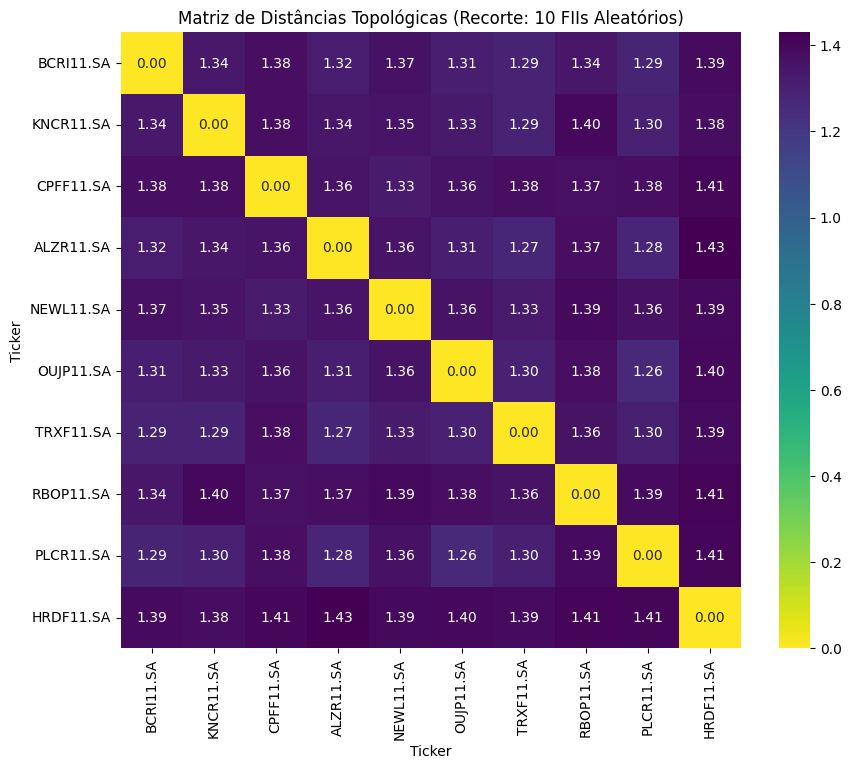

In [5]:
# Cálculo do Retorno Logarítmico Diário (Métrica padrão em finanças quantitativas)
# R = ln(Preço_Hoje / Preço_Ontem)
retornos = np.log(dados_limpos / dados_limpos.shift(1)).dropna()

# Matriz de Correlação
matriz_corr = retornos.corr()

# Transformação Geométrica (Distância Euclidiana)
matriz_distancias = np.sqrt(2 * (1 - matriz_corr))

# Sorteando 10 fundos aleatórios da nossa matriz
# Usamos random_state=42 para que toda vez que você rodar a apresentação, os mesmos 10 fundos "aleatórios" apareçam.
# Se quiser que mude a cada execução, basta apagar o "random_state=42".
fundos_aleatorios = matriz_distancias.sample(n = 10, axis = 1, random_state = 42).columns

# Recortando a matriz quadrada exata (linhas e colunas) dos 10 fundos sorteados
matriz_recorte = matriz_distancias.loc[fundos_aleatorios, fundos_aleatorios]

# Preview Visual da Interdependência
plt.figure(figsize = (10, 8)) # Aumentei levemente o tamanho para os nomes não ficarem espremidos
sns.heatmap(matriz_recorte, annot = True, cmap = 'viridis_r', fmt = ".2f")
plt.title("Matriz de Distâncias Topológicas (Recorte: 10 FIIs Aleatórios)")
plt.show()

A matriz de distâncias topológicas apresenta um mapa de calor onde as células mais escuras indicam conexões fortes (baixo risco de contágio) e as mais claras revelam relações fracas (alto risco de contágio). Este é o terreno fértil onde a Teoria dos Grafos irá florescer, permitindo-nos identificar os "Hubs" de risco e os agrupamentos naturais de FIIs.

---

## 5. Modelagem

A modelagem de ativos financeiros via Teoria de Redes exige uma estrutura de filtragem robusta para limpar o ruído (correlações espúrias) de uma matriz densa, onde "todo mundo parece conectado a todo mundo".

Uma dúvida comum na engenharia de dados financeiros é: "Por que não simplificar a abordagem e apenas deletar as arestas com correlações mais fracas?". Este método direto é conhecido como **Rede de Limiar (_Threshold Network_)**.

Para testar essa hipótese, automatizamos a simulação de 50 cortes de correlação progressivos no mercado de FIIs, mapeando o número de arestas sobreviventes e a fragmentação da rede em "ilhas".

In [6]:
# =====================================================================
# TRANSIÇÃO DE FASE: CURVA DE PERCOLAÇÃO DO MERCADO (THRESHOLD vs PMFG)
# =====================================================================
import plotly.graph_objects as go
from plotly.subplots import make_subplots

print("🔬 Automatizando testes de Threshold para desenhar a Curva de Percolação...")

cortes_correlacao = np.linspace(0.00, 0.50, 50)
historico_arestas = []
historico_componentes = []
colunas = matriz_distancias.columns

for corte in cortes_correlacao:
    dist_corte = np.sqrt(2 * (1 - corte))
    
    # Cria o grafo temporário para este corte
    G_temp = nx.Graph()
    G_temp.add_nodes_from(colunas)
    
    arestas_validas = []
    for i in range(len(colunas)):
        for j in range(i + 1, len(colunas)):
            if matriz_distancias.iloc[i, j] < dist_corte:
                arestas_validas.append((colunas[i], colunas[j]))
                
    G_temp.add_edges_from(arestas_validas)
    
    # Registra os resultados
    historico_arestas.append(G_temp.number_of_edges())
    historico_componentes.append(nx.number_connected_components(G_temp))

# =================================
# RENDERIZAÇÃO DO GRÁFICO (PLOTLY)
# =================================
fig = make_subplots(specs = [[{"secondary_y": True}]])

# Linha 1: Queda das Arestas (Ruído)
fig.add_trace(
    go.Scatter(x = cortes_correlacao,
               y = historico_arestas,
               name = "Qtd. Arestas Sobreviventes",
               mode = 'lines',
               line = dict(color = '#00F3FF', width = 3)),
    secondary_y = False,
)

# Linha 2: Aumento das Ilhas (Fragmentação)
fig.add_trace(
    go.Scatter(x = cortes_correlacao,
               y = historico_componentes,
               name = "Qtd. Ilhas (Componentes)",
               mode = 'lines',
               line = dict(color = '#FF0055', width = 3)),
    secondary_y = True,
)

# Linha do PMFG (Referência de Ouro)
arestas_pmfg = 3 * 77 - 6 # 225
fig.add_hline(y = arestas_pmfg,
              line_dash = "dash",
              line_color = "#00FF41", 
              annotation_text = "Alvo PMFG (225 arestas)", 
              secondary_y = False)

# Configuração do Layout Dark
fig.update_layout(
    title = "Análise de Percolação: O Colapso Topológico do Método Threshold",
    template = "plotly_dark",
    paper_bgcolor = '#140524',
    plot_bgcolor = '#140524',
    xaxis_title = "Corte de Correlação Mínima Exigida",
    hovermode = "x unified",
    legend = dict(yanchor = "top", y = 0.99, xanchor = "right", x = 0.95)
)

fig.update_yaxes(title_text = "Número de Arestas (Densidade)", secondary_y = False, color = '#00F3FF')
fig.update_yaxes(title_text = "Número de Ilhas (Fragmentação)", secondary_y = True, color = '#FF0055')

fig.show()

🔬 Automatizando testes de Threshold para desenhar a Curva de Percolação...


Como observado no gráfico de percolação gerado, a abordagem de Limiar sofre de uma falha matemática intransponível conhecida como Transição de Fase:

- **O Excesso de Ruído (Limiares Baixos):** Se formos brandos com o corte de correlação, a rede não se rompe, mas é inundada por conexões. O mercado vira um bloco denso de ruído estatístico (mais de **2.000 arestas**) onde é impossível distinguir o sinal principal e mapear comunidades claras.

- **O Estilhaçamento (Limiares Altos):** À medida que o corte se torna rigoroso, a rede sofre uma **Transição de Fase**. No ponto de cruzamento das métricas no gráfico (corte de **0.16**), restam apenas **617 arestas**, mas a estrutura central já colapsou em **19 ilhas isoladas**. A liquidez sistêmica parou de fluir globalmente.

Para contornar essa limitação e capturar a verdadeira complexidade do IFIX, este projeto adota o **Planar Maximally Filtered Graph (PMFG)** como arquitetura primária. A prova irrefutável do nosso método reside na linha tracejada verde (*Alvo PMFG: 225 arestas*). 

Se tentássemos usar o método *Threshold* para limpar o gráfico até restarem apenas 225 arestas (o que ocorre com um corte próximo a **0.21**), a linha vermelha revela que o mercado estaria destroçado em **mais de 25 ilhas isoladas**, impossibilitando qualquer cálculo de contágio ou centralidade global (*Eigenvector* ou *PageRank*).

A abordagem clássica em Econofísica costumava ser a Árvore Geradora Mínima (MST). No entanto, a MST é excessivamente simplista: por proibir a formação de ciclos (loops), ela destrói os "triângulos de risco mútuo" e as vias secundárias de contágio que existem na vida real.

O PMFG é uma abstração topológica superior porque permite que os $V$ fundos (vértices) se conectem utilizando até $3V - 6$ arestas, sob uma única restrição geométrica estrita: a planaridade. Ou seja, a rede é construída permitindo ciclos e cliques densos de até 4 fundos (tetraedros topológicos), mas de forma que nenhuma linha de correlação cruze outra no espaço bidimensional. Isso preserva a capilaridade e as retroalimentações do mercado sem transformá-lo em um "novelo de lã" ilegível.

### 💻 5.1. Construção da Topologia e Mapeamento de Risco

A célula de código a seguir executa o pipeline de modelagem topológica e extração de métricas de centralidade. Ao invés de dependermos de um único indicador, utilizamos quatro motores matemáticos distintos para mapear como o risco flui pela estrutura do PMFG:

1. **Construção do PMFG:** O motor varre a nossa matriz de distâncias iterativamente (do mais correlacionado para o menos), adicionando arestas apenas se o grafo resultante passar no teste de planaridade geométrica (Algoritmo de Boyer-Myrvold).

2. **Eigenvector Centrality (Vetor de Risco Sistêmico):** Aplicamos o Método das Potências para identificar os grandes *Hubs* da rede. Diferente do grau simples, o Autovetor avalia a qualidade da conexão: um fundo é sistemicamente perigoso se estiver conectado a outros fundos também perigosos. Ou também podemos dizer que mede o "contágio", i.e, um fundo ganha nota alta se ele estiver conectado a outros fundos de nota alta, como um vírus.\
A equação matemática clássica na Teoria de Redes é descrita pelo problema de autovalores e autovetores:

$$x_v = \frac{1}{\lambda} \sum_{t \in G} a_{v,t} x_t$$

Ou, na sua forma matricial mais elegante:

$$Ax = \lambda x$$
<!-- A Anatomia da Fórmula:

- $x_v$: É a pontuação de Risco Sistêmico (a centralidade) do fundo imobiliário $v$ que estamos calculando.
- $a_{v,t}$: É o valor da conexão entre o fundo $v$ e o fundo $t$. No seu projeto, isso é exatamente aquela sua variável sim_eigen = max(0.0, 2.0 - distancia). Se eles não têm conexão, isso vale $0$.
- $x_t$: É a pontuação de Risco Sistêmico do vizinho $t$. (Note que o escore de $v$ depende diretamente do escore de $t$).
- $\lambda$ (Lambda): É o Maior Autovalor da matriz de adjacência. Ele atua como uma constante de normalização matemática. Sem ele, como a fórmula soma a importância dos vizinhos infinitamente, os números explodiriam para o infinito. O $\lambda$ "freia" o cálculo para que as notas se estabilizem (geralmente entre 0 e 1). -->

> Fórmula explicada por Phillip Bonacich em seu artigo "Power and Centrality: A Family of Measures" (publicado na revista American Journal of Sociology em 1987); e também: "Factoring and weighting approaches to status scores and clique identification." (publicado na revista Journal of Mathematical Sociology em 1991).

3. **Betweenness Centrality (Pontes de Liquidez):** Avalia quais vértices funcionam como "gargalos" obrigatórios entre setores distintos. Um fundo com alto Betweenness controla o fluxo de correlação entre áreas isoladas da rede.
$$g(v) = \sum_{s \neq v \neq t} \frac{\sigma_{st}(v)}{\sigma_{st}}$$
> Fórmula explicada por Linton C. Freeman em seu artigo "A Set of Measures of Centrality Based on Betweenness" (publicado na revista Sociometry em 1977).

4. **PageRank Centrality (Acúmulo de Pânico):** Criado pelo Google, é parecido com o Eigenvector, mas possui um "fator de amortecimento" (Damping Factor). Na prática financeira, ele responde: "Se um investidor pular aleatoriamente de fundo em fundo seguindo as correlações, onde o dinheiro dele tem maior probabilidade de ficar preso?"
$$PR(v) = \frac{1 - d}{N} + d \sum_{t \in M(v)} \frac{PR(t)}{L(t)}$$

> Fórmula explicada por Sergey Brin e Lawrence Page em seu artigo "The Anatomy of a Large-Scale Hypertextual Web Search Engine" (publicado na revista Computer Networks and ISDN Systems em 1998).

5. **Closeness Centrality (Velocidade de Propagação):** Mede a proximidade média de um nó para todos os outros. Na economia, isso mede a velocidade. Se um fundo com alto Closeness quebrar, o pânico atinge o mercado inteiro em menos "dias" (saltos) do que se um fundo com baixo Closeness quebrasse.
$$C(v) = \frac{N - 1}{\sum_{t \neq v} d(v, t)}$$

> Fórmula explicada por Linton C. Freeman em seu artigo "Centrality in Social Networks: Conceptual Clarification" (publicado na revista Social Networks em 1978).

In [7]:
# ===================================================
# MOTOR DO ALGORITMO PMFG (Para o Universo Completo)
# ===================================================

# Vetorizar e ordenar todas as distâncias possíveis
arestas = []
colunas = matriz_distancias.columns
for i in range(len(colunas)):
    for j in range(i + 1, len(colunas)):
        d = matriz_distancias.iloc[i, j]
        if not np.isnan(d):
            arestas.append((d, colunas[i], colunas[j]))

arestas.sort(key = lambda x: x[0]) 

# Construção iterativa do PMFG
PMFG = nx.Graph()
PMFG.add_nodes_from(colunas)

limite_arestas = 3 * len(PMFG.nodes) - 6
arestas_adicionadas = 0

print("⚙️ Compilando Topologia Planar (PMFG)...")
for d, u, v in arestas:
    if arestas_adicionadas >= limite_arestas:
        break
        
    PMFG.add_edge(u, v, weight=d)
    
    is_planar, _ = nx.check_planarity(PMFG)
    if is_planar:
        arestas_adicionadas += 1
    else:
        PMFG.remove_edge(u, v)

print(f"🕸️ Grafo Concluído: {len(PMFG.nodes)} vértices e {len(PMFG.edges)} arestas.")

⚙️ Compilando Topologia Planar (PMFG)...
🕸️ Grafo Concluído: 77 vértices e 225 arestas.


---

In [10]:
# ================================================================
# ESTUDO DE CENTRALIDADES MÚLTIPLAS NO PMFG (Mapeamento de Risco)
# ================================================================

print("🧠 Calculando múltiplas dimensões de risco sistêmico no PMFG...\n")

# 1. Preparação dos Pesos (Distância vs Similaridade)
for u, v, d in PMFG.edges(data = True):
    distancia = d['weight']
    PMFG[u][v]['sim_eigen'] = max(0.0, 2.0 - distancia)
    
# 2. Injeção de Metadados Setoriais
for fundo in PMFG.nodes():
    PMFG.nodes[fundo]['setor'] = setores_reais.get(fundo, 'Outros')

# ==========================
# 2. CÁLCULO DAS 4 MÉTRICAS
# ==========================
cent_betw = nx.betweenness_centrality(PMFG, weight = 'weight')
nx.set_node_attributes(PMFG, cent_betw, 'cent_betw')

cent_eigen = nx.eigenvector_centrality(PMFG, 
                                       max_iter = 5000,
                                       tol = 1e-04,
                                       weight = 'sim_eigen')
nx.set_node_attributes(PMFG, cent_eigen, 'cent_eigen')

cent_page = nx.pagerank(PMFG, 
                        alpha = 0.85,
                        weight = 'sim_eigen')
nx.set_node_attributes(PMFG, cent_page, 'cent_page')

cent_close = nx.closeness_centrality(PMFG, distance = 'weight')
nx.set_node_attributes(PMFG, cent_close, 'cent_close')

# =====================================================
# 3. EXIBIÇÃO ANALÍTICA (O Painel de Controle - TOP 7)
# =====================================================
# Atualizamos a função para extrair os 7 maiores Hubs
def imprimir_top(dicionario_centralidade, titulo, descricao, top_n = 7):
    # Pega os N maiores valores
    top_rank = sorted(dicionario_centralidade.items(), key = lambda x: x[1], reverse = True)[:top_n]
    print(f"🏆 {titulo}")
    print(f"   {descricao}")
    for i, (fundo, nota) in enumerate(top_rank, 1):
        setor = setores_reais.get(fundo, 'Outros')
        print(f"   {i}º) {fundo.replace('.SA','')}: {nota:.4f} ({setor})")
    print("-" * 60)

print("=" * 60)
imprimir_top(cent_eigen, "EIGENVECTOR (Efeito Dominó)", "Fundos mais conectados a outros fundos gigantes.")
imprimir_top(cent_betw, "BETWEENNESS (Pontes de Liquidez)", "Fundos que conectam setores isolados do mercado.")
imprimir_top(cent_page, "PAGERANK (Acúmulo de Risco)", "Para onde o capital/pânico flui aleatoriamente.")
imprimir_top(cent_close, "CLOSENESS (Velocidade de Contágio)", "Fundos que atingem o mercado inteiro em menos passos.")
print("✅ Análise Analítica Concluída!")
print("=" * 60)

# ==============================================
# 4. EXPORTAÇÃO DOS ARTEFATOS VISUAIS (4 HTMLs)
# ==============================================
os.makedirs('html', exist_ok = True)

metricas = [
    ('cent_eigen', 'Eigenvector', 'pmfg_risco_eigenvector.html'),
    ('cent_betw', 'Betweenness', 'pmfg_risco_betweenness.html'),
    ('cent_page', 'PageRank', 'pmfg_risco_pagerank.html'),
    ('cent_close', 'Closeness', 'pmfg_risco_closeness.html')
]

for atributo_node, nome_metrica, nome_arquivo in metricas:
    net = Network(notebook = False,
                  width = "100%", 
                  height = "700px", 
                  bgcolor = "#140524",
                  font_color = "#EAE0F9",
                  cdn_resources = 'remote')
    net.force_atlas_2based()
    
    max_val = max(nx.get_node_attributes(PMFG, atributo_node).values())
    if max_val == 0: max_val = 1 
    
    for fundo in PMFG.nodes():
        setor_fundo = PMFG.nodes[fundo]['setor']
        valor_metrica = PMFG.nodes[fundo][atributo_node]
        
        cor_no = '#00F3FF' 
        
        texto_hover = (f"Ticker: {fundo.replace('.SA', '')}\n"
                       f"Setor B3: {setor_fundo}\n"
                       f"{nome_metrica}: {valor_metrica:.4f}")
        
        tamanho = 10 + ((valor_metrica / max_val) * 80)
        
        net.add_node(fundo, label = fundo.replace('.SA', ''), color = cor_no, size = tamanho, title = texto_hover)

    for u, v in PMFG.edges():
        net.add_edge(u, v, color='rgba(234, 224, 249, 0.25)', width = 1.5)

    caminho_completo = f'html/center/{nome_arquivo}'
    net.save_graph(caminho_completo)

print(f"✅ Sucesso! 4 grafos HTML dimensionados foram salvos na pasta 'html/center/'.")

🧠 Calculando múltiplas dimensões de risco sistêmico no PMFG...

🏆 EIGENVECTOR (Efeito Dominó)
   Fundos mais conectados a outros fundos gigantes.
   1º) VISC11: 0.3544 (Shoppings)
   2º) XPLG11: 0.3288 (Logística)
   3º) HSML11: 0.3125 (Shoppings)
   4º) MFII11: 0.2744 (Desenvolvimento)
   5º) XPML11: 0.2635 (Shoppings)
   6º) TRXF11: 0.1939 (Renda Urbana)
   7º) HGRU11: 0.1921 (Renda Urbana)
------------------------------------------------------------
🏆 BETWEENNESS (Pontes de Liquidez)
   Fundos que conectam setores isolados do mercado.
   1º) VISC11: 0.3144 (Shoppings)
   2º) MFII11: 0.3105 (Desenvolvimento)
   3º) XPLG11: 0.2389 (Logística)
   4º) HSML11: 0.1940 (Shoppings)
   5º) XPML11: 0.1614 (Shoppings)
   6º) VILG11: 0.1446 (Logística)
   7º) RBRF11: 0.0919 (FoF)
------------------------------------------------------------
🏆 PAGERANK (Acúmulo de Risco)
   Para onde o capital/pânico flui aleatoriamente.
   1º) VISC11: 0.0442 (Shoppings)
   2º) MFII11: 0.0414 (Desenvolvimento)
  

### 5.2. Aprendizado Não Supervisionado e Risco Sistêmico

Com a topologia do PMFG matematicamente validada e o espaço geométrico definido, o próximo passo é a identificação de pólos de risco sistêmico e a detecção de comunidades ("bairros de contágio"). E para garantir o rigor científico da nossa análise, não dependemos de um único método. Colocamos à prova 4 algoritmos com filosofias matemáticas estruturalmente opostas para descobrir qual deles mapeia o risco do IFIX com maior precisão e viabilidade computacional:

1. 🥇 **Louvain (Otimização Heurística):** Abordagem *Bottom-up*. Agrupa nós locais rapidamente para maximizar a densidade interna e, em seguida, trata esses grupos consolidados como novos "super-nós" em múltiplas fases. Representa o equilíbrio ideal entre precisão topológica e velocidade de execução.

2. ✂️ **Girvan-Newman (Abordagem Divisiva):** Metodologia *Top-down*. Enxerga o mercado inicialmente como um bloco único e vai "cortando as pontes" sistêmicas (deletando as arestas com maior *Betweenness Centrality*) até a rede se estilhaçar em nichos isolados. É uma abordagem matematicamente cirúrgica, porém com um custo computacional extremamente elevado.

3. 🦠 **Label Propagation (Propagação Epidêmica):** Abordagem por consenso de vizinhança. Cada fundo "vota" e adota iterativamente o setor/cluster predominante ao seu redor. É um algoritmo ultrarrápido por não calcular métricas globais, mas tende a ser caótico e instável em mercados muito densos.

4. 🧩 **Greedy Modularity (Aglomerativo Estrito):** Otimização gulosa (*Clauset-Newman-Moore*). Inicia com os 77 fundos isolados e, a cada passo, funde o par exato que gera o maior aumento imediato de Modularidade ($Q$). Ele toma decisões ótimas de curto prazo, ignorando a otimização global a longo prazo.

In [11]:
# ===================================================
# BENCHMARKING DE COMUNIDADES (Metodologia Raj Jain)
# ===================================================
import time # Usado para medir o tempo de execução dos algoritmos
import itertools # Usado para limitar o número de iterações do Girvan-Newman

# 1. Garantindo que o peso de Similaridade está configurado para a IA
for u, v, d in PMFG.edges(data = True):
    distancia = d['weight']
    PMFG[u][v]['sim_louvain'] = max(0.0, 2.0 - distancia)

resultados_benchmark = []

# ==============================
# TESTE 1: Algoritmo de Louvain 
# ==============================
t_inicio = time.perf_counter()
comms_louvain = nx_comm.louvain_communities(PMFG, weight = 'sim_louvain', seed = 42)
t_fim = time.perf_counter()

mod_louvain = nx_comm.modularity(PMFG, comms_louvain, weight='sim_louvain')
resultados_benchmark.append({
    'Algoritmo': 'Louvain (Otimização Heurística)',
    'Filosofia': 'Bottom-up / Multi-fase',
    'Complexidade': 'O(N log N)',
    'Tempo (ms)': (t_fim - t_inicio) * 1000,
    'Qtd. Clusters': len(comms_louvain),
    'Modularidade (Q)': mod_louvain
})

# =======================
# TESTE 2: Girvan-Newman 
# =======================
t_inicio = time.perf_counter()

def aresta_mais_valiosa(grafo):
    centralidade_arestas = nx.edge_betweenness_centrality(grafo, weight = 'weight')
    return max(centralidade_arestas, key = centralidade_arestas.get)

# Passamos a nossa função como regra de corte
gn_generator = nx_comm.girvan_newman(PMFG, most_valuable_edge = aresta_mais_valiosa) 

melhor_mod_gn = -1
melhor_comms_gn = None

for particoes in itertools.islice(gn_generator, 10): 
    mod_atual = nx_comm.modularity(PMFG, particoes, weight = 'sim_louvain')
    if mod_atual > melhor_mod_gn:
        melhor_mod_gn = mod_atual
        melhor_comms_gn = particoes
        
t_fim = time.perf_counter()

resultados_benchmark.append({
    'Algoritmo': 'Girvan-Newman',
    'Filosofia': 'Top-down / Divisivo',
    'Complexidade': 'O(E² N)',
    'Tempo (ms)': (t_fim - t_inicio) * 1000,
    'Qtd. Clusters': len(melhor_comms_gn) if melhor_comms_gn else 0,
    'Modularidade (Q)': melhor_mod_gn
})

# ===========================
# TESTE 3: Label Propagation 
# ===========================
t_inicio = time.perf_counter()
# Usa LPA assíncrono para grafos ponderados
comms_lpa = list(nx_comm.asyn_lpa_communities(PMFG, weight = 'sim_louvain', seed = 42))
t_fim = time.perf_counter()

mod_lpa = nx_comm.modularity(PMFG, comms_lpa, weight = 'sim_louvain')
resultados_benchmark.append({
    'Algoritmo': 'Label Propagation',
    'Filosofia': 'Epidêmico / Consenso Local',
    'Complexidade': 'O(E)',
    'Tempo (ms)': (t_fim - t_inicio) * 1000,
    'Qtd. Clusters': len(comms_lpa),
    'Modularidade (Q)': mod_lpa
})

# ===========================
# TESTE 4: Greedy Modularity 
# ===========================
t_inicio = time.perf_counter()
comms_greedy = list(nx_comm.greedy_modularity_communities(PMFG, weight = 'sim_louvain'))
t_fim = time.perf_counter()

mod_greedy = nx_comm.modularity(PMFG, comms_greedy, weight = 'sim_louvain')
resultados_benchmark.append({
    'Algoritmo': 'Greedy Modularity',
    'Filosofia': 'Aglomerativo Hierárquico',
    'Complexidade': 'O(N log² N)',
    'Tempo (ms)': (t_fim - t_inicio) * 1000,
    'Qtd. Clusters': len(comms_greedy),
    'Modularidade (Q)': mod_greedy
})

# ==============================
# EXIBIÇÃO DA TABELA DE DECISÃO 
# ==============================
df_benchmark = pd.DataFrame(resultados_benchmark)

# Formatando os números para ficarem bonitos na tabela
df_benchmark['Tempo (ms)'] = df_benchmark['Tempo (ms)'].apply(lambda x: f"{x:.2f} ms")
df_benchmark['Modularidade (Q)'] = df_benchmark['Modularidade (Q)'].apply(lambda x: f"{x:.4f}")

# Reordena do melhor (maior Q) para o pior
df_benchmark = df_benchmark.sort_values(by = 'Modularidade (Q)', ascending = False).reset_index(drop = True)

print("Veja o ranking de performance:")
display(df_benchmark)

Veja o ranking de performance:


,Algoritmo,Filosofia,Complexidade,Tempo (ms),Qtd. Clusters,Modularidade (Q)
0,Louvain (Otimização Heurística),Bottom-up / Multi-fase,O(N log N),14.29 ms,5,0.5345
1,Greedy Modularity,Aglomerativo Hierárquico,O(N log² N),45.45 ms,5,0.5265
2,Girvan-Newman,Top-down / Divisivo,O(E² N),3861.66 ms,6,0.5105
3,Label Propagation,Epidêmico / Consenso Local,O(E),11.48 ms,6,0.3912


In [12]:
# ================================================
# DEPLOYMENT VISUAL DOS ALGORITMOS DE COMUNIDADES
# ================================================

# 1. Criando o diretório isolado para os testes de IA
os.makedirs('html/comm', exist_ok = True)

print("🎨 Gerando a renderização visual das comunidades...\n")

# Paleta de cores estendida e vibrante para garantir que todos os clusters tenham cores únicas
paleta_ia = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEEAD', 
             #D4A5A5', '#9B59B6', '#3498DB', '#E67E22', '#2ECC71',
             '#F1C40F', '#E74C3C', '#8E44AD', '#34495E', '#16A085']

def exportar_comunidade(comunidades, nome_algoritmo, arquivo_saida):
    """
    Função automatizada que injeta os IDs de cluster nos nós 
    e exporta a rede no padrão estético Royal Purple.
    """
    # 1. Criar um dicionário reverso: Qual fundo está em qual cluster?
    mapa_clusters = {}
    for id_cluster, cluster in enumerate(comunidades):
        for fundo in cluster:
            mapa_clusters[fundo] = id_cluster
            
    # 2. Configurar o Motor de Física (PyVis)
    net = Network(notebook = False,
                  width = "100%",
                  height = "700px", 
                  bgcolor = "#140524",
                  font_color = "#EAE0F9",
                  cdn_resources = 'remote')
    net.force_atlas_2based()
    
    # 3. Adicionar Nós Coloridos por Machine Learning
    for fundo in PMFG.nodes():
        id_cluster = mapa_clusters.get(fundo, 0)
        setor_fundo = setores_reais.get(fundo, 'Outros')
        
        # Resgata a influência se existir para o tamanho (ou deixa um padrão)
        risco = PMFG.nodes[fundo].get('influencia', 0.1)
        
        cor_no = paleta_ia[id_cluster % len(paleta_ia)]
        
        texto_hover = (f"Ticker: {fundo.replace('.SA', '')}\n"
                       f"Setor B3: {setor_fundo}\n"
                       f"Algoritmo: {nome_algoritmo}\n"
                       f"Comunidade IA: Cluster {id_cluster + 1}")
        
        tamanho = 10 + (risco * 120)
        
        net.add_node(fundo, 
                     label = fundo.replace('.SA', ''),
                     color = cor_no, 
                     size = tamanho,
                     title = texto_hover)

    # 4. Desenhar Arestas
    for u, v in PMFG.edges():
        net.add_edge(u, v, color='rgba(234, 224, 249, 0.25)', width = 1.5)
        
    # 5. Salvar Fisicamente
    caminho_completo = f"html/comm/{arquivo_saida}"
    net.save_graph(caminho_completo)
    print(f"✅ Exportado: {nome_algoritmo.ljust(20)} -> {caminho_completo}")

# ===========================
# 2. DISPARO DAS EXPORTAÇÕES 
# ===========================

exportar_comunidade(comms_louvain, "Louvain", "pmfg_comm_louvain.html")

if melhor_comms_gn: # Tratamento de erro caso o GN tenha falhado
    exportar_comunidade(melhor_comms_gn, "Girvan-Newman", "pmfg_comm_girvan_newman.html")

exportar_comunidade(comms_lpa, "Label Propagation", "pmfg_comm_label_propagation.html")
exportar_comunidade(comms_greedy, "Greedy Modularity", "pmfg_comm_greedy.html")

print("\nAbra a pasta 'html/comm/' e compare o comportamento visual de cada I.A.")

🎨 Gerando a renderização visual das comunidades...

✅ Exportado: Louvain              -> html/comm/pmfg_comm_louvain.html
✅ Exportado: Girvan-Newman        -> html/comm/pmfg_comm_girvan_newman.html
✅ Exportado: Label Propagation    -> html/comm/pmfg_comm_label_propagation.html
✅ Exportado: Greedy Modularity    -> html/comm/pmfg_comm_greedy.html

Abra a pasta 'html/comm/' e compare o comportamento visual de cada I.A.


> Por buscarmos uma abordagem completa e robusta, logo abaixo estaremos nos aprofundando no conceito que cada um aborda. Mas você é livre para pular esta seção e ir direto para a análise de resultados caso queira visto que esta abordagem é mais acadêmica e matemática. Lembrando que em nosso relatório que está disponível você também pode encontrar a explicação de todo nosso projeto. E em nosso aplicativo web, você pode interagir com a rede e explorar os clusters de risco de forma dinâmica.

### **Algoritmos de Detecção de Comunidades**

#### 🥇 Otimização de Modularidade (Algoritmo de Louvain)

Para quebrar os rótulos nominais da B3 e descobrir os verdadeiros "blocos de risco" operando no mercado, aplicamos o aprendizado de máquina não supervisionado através do **Algoritmo de Louvain**.

Diferente de métodos baseados em distância (como o K-Means), o Louvain é um algoritmo heurístico focado na maximização de uma métrica topológica chamada **Modularidade ($Q$)**. A modularidade quantifica a densidade das conexões *dentro* de uma comunidade em comparação com o que seria matematicamente esperado em uma rede gerada ao acaso (Modelo Nulo).



A função objetivo maximizada pelo algoritmo é dada por:

$$Q = \frac{1}{2m} \sum_{i,j} \left[ A_{ij} - \frac{k_i k_j}{2m} \right] \delta(c_i, c_j)$$

**Anatomia da Equação no Contexto do Projeto:**
* $Q$: A pontuação de Modularidade (varia tipicamente entre $-0.5$ e $+1.0$). O algoritmo move os FIIs de um grupo para outro até que $Q$ não possa mais crescer.
* $A_{ij}$: O peso real da conexão (Matriz de Adjacência) entre o fundo $i$ e o fundo $j$. É exatamente aqui que injetamos a nossa transformação de similaridade $(2.0 - d)$, garantindo que o algoritmo interprete distâncias curtas como fortes forças de atração.
* $k_i$ e $k_j$: A soma de todos os pesos das arestas conectadas aos fundos $i$ e $j$ (seus graus ponderados).
* $\frac{k_i k_j}{2m}$: O **Modelo Nulo**. Representa a probabilidade teórica de dois fundos estarem conectados caso as conexões do mercado fossem puramente aleatórias, onde $m$ é a soma de todas as arestas da rede.
* $\delta(c_i, c_j)$: A função Delta de Kronecker. Ela atua como uma "chave lógica": vale $1$ se o algoritmo decidir colocar os fundos $i$ e $j$ na mesma comunidade ($c_i = c_j$), e vale $0$ caso contrário.

O resultado é uma clusterização orgânica que agrupa fundos não pelo nome do seu setor oficial, mas pela forma como eles co-movimentam seu capital em cenários de estresse.

> *Fundamentação Teórica baseada no artigo seminal "Fast unfolding of communities in large networks", publicado por Vincent D. Blondel, Jean-Loup Guillaume, Renaud Lambiotte e Etienne Lefebvre (Journal of Statistical Mechanics: Theory and Experiment, 2008).*

#### ✂️ **Divisão por Centralidade de Arestas (Algoritmo de Girvan-Newman)**

Para atuar de forma diametralmente oposta ao Louvain, aplicamos o **Algoritmo de Girvan-Newman**, um modelo divisivo (Top-down). Enquanto a maioria dos algoritmos tenta "juntar" nós semelhantes, o Girvan-Newman foca em encontrar e destruir os pontos de contato entre os blocos, isolando as comunidades por exclusão.

O algoritmo calcula iterativamente a **Centralidade de Intermediação de Arestas (Edge Betweenness Centrality)** e remove a aresta com a maior pontuação. A equação fundamental que dita esse corte é:

$$C_B(e) = \sum_{s \neq t} \frac{\sigma_{st}(e)}{\sigma_{st}}$$

Anatomia da Equação no Contexto do Projeto:

- **$C_B(e)$:** A pontuação de intermediação da aresta $e$ (a conexão entre dois FIIs). Representa o tamanho do "pedágio" que aquela conexão cobra na rede. O algoritmo recalcula essa métrica a cada rodada e corta a linha de maior valor.
- **$\sigma_{st}$:** O número total de caminhos mais curtos (shortest paths) matematicamente possíveis para viajar do fundo $s$ até o fundo $t$, utilizando a matriz de distâncias geométrica do PMFG.
- **$\sigma_{st}(e)$:** A quantidade exata desses caminhos mais curtos que são obrigados a passar por cima da aresta $e$ para chegar ao destino.
- **$\sum_{s \neq t}$:** O somatório de controle que computa essa fração para absolutamente todos os pares concebíveis de FIIs na topologia.

Ao cortar as arestas onde $\frac{\sigma_{st}(e)}{\sigma_{st}}$ é máximo, o algoritmo está estilhaçando as "pontes" que ligavam bairros de risco distantes (como o bloco de Shoppings e o bloco de Papel), forçando a rede a se separar de forma limpa.

> Fundamentação Teórica baseada no artigo seminal "Community structure in social and biological networks", publicado por Michelle Girvan e Mark E. J. Newman (Proceedings of the National Academy of Sciences - PNAS, 2002).


#### 🦠 **Difusão Epidêmica e Consenso (Label Propagation Algorithm - LPA)**

Para avaliar a viabilidade de sistemas de alta frequência e baixo custo computacional, implementamos o **Algoritmo de Propagação de Rótulos (LPA)**. Diferente do Louvain e do Girvan-Newman, o LPA não tenta otimizar nenhuma função global de modularidade; ele opera por uma dinâmica epidemiológica de consenso local.

Em sua versão assíncrona ponderada (aplicada sobre o nosso PMFG), a regra de atualização do rótulo (comunidade) do fundo $i$ no tempo $t+1$ é governada pela equação:

$$c_i^{(t+1)} = \arg\max_{l} \sum_{j \in N(i)} w_{ij} \cdot \delta(c_j^{(t)}, l)$$

Anatomia da Equação no Contexto do Projeto:
- **$c_i^{(t+1)}$:** O novo rótulo (a comunidade IA) que o fundo imobiliário $i$ vai assumir na próxima rodada de votação.
- **$\arg\max_{l}$:** Uma função de decisão estrita. Ela escolhe o rótulo específico $l$ que obteve a maior força de voto ponderada entre todos os vizinhos.
- **$N(i)$:** A vizinhança imediata do fundo $i$. O algoritmo olha apenas para os fundos que possuem uma linha direta de conexão com ele no PMFG, ignorando o resto do mercado.
- **$w_{ij}$:** O peso da aresta (força de atração). Aqui opera a nossa transformação de similaridade sim_louvain $(2.0 - d)$. Isso significa que vizinhos muito correlacionados têm um "voto" muito mais pesado na decisão do fundo $i$ do que vizinhos distantes.
- **$\delta(c_j^{(t)}, l)$:** O Delta de Kronecker atuando como filtro ativador. Vale $1$ se o vizinho $j$ estiver atualmente usando o rótulo $l$, e $0$ caso contrário.

O processo se encerra quando cada fundo do IFIX estiver usando o mesmo rótulo que a maioria ponderada de seus vizinhos adjacentes, estabilizando a propagação.

>Fundamentação Teórica baseada no artigo seminal "Near linear time algorithm to detect community structures in large-scale networks", publicado por Usha Nandini Raghavan, Réka Albert e Sri Kumara (Physical Review E, 2007); e também: "Community detection via graph regularized symmetric nonnegative matrix tri-factorization", publicado por Hazhir Sohrabi, Shahrokh Esmaeili e Parham Moradi (The Journal of Supercomputing, 2026).


#### 🧩 **Otimização Gulosa de Estrutura (Greedy Modularity Maximization)**

Como técnica de validação comparativa direta ao Louvain, adotamos o algoritmo **Greedy Modularity (Clauset-Newman-Moore)**. Embora ambos busquem maximizar a Modularidade ($Q$), a estratégia de busca é completamente diferente: o Greedy é uma abordagem aglomerativa hierárquica estrita e unidirecional.

O algoritmo inicia considerando que cada um dos fundos é uma comunidade isolada e, a cada passo, une o par de comunidades que gera o maior ganho imediato ($\Delta Q$) na função objetivo, calculado por:

$$\Delta Q = \frac{A_{ij}}{m} - \frac{k_i k_j}{2m^2}$$

Anatomia da Equação no Contexto do Projeto:
- **$\Delta Q$:** O incremento (ganho) de modularidade global caso o algoritmo decida fundir o fundo $i$ e o fundo $j$ no mesmo grupo. Se nenhuma fusão possível gerar um $\Delta Q > 0$, o algoritmo para.
- **$A_{ij}$:** O peso real medido pela matriz de adjacência de similaridade entre o fundo $i$ e o fundo $j$. Representa a força de atração real do mercado.
- **$m$:** A soma total dos pesos de todas as arestas sobreviventes no PMFG. Atua como o fator de escala global do sistema econômico.
- **$k_i$ e $k_j$:** Os graus ponderados (soma das similaridades) dos fundos $i$ e $j$, respectivamente.
- **$\frac{k_i k_j}{2m^2}$:** O termo de penalização do Modelo Nulo. Ele calcula qual seria a probabilidade desses dois fundos estarem unidos se o mercado fosse puramente aleatório.

A natureza "Gulosa" (Greedy) reside no fato de que o algoritmo escolhe a melhor opção local de curto prazo a cada linha de código, o que o torna uma excelente métrica de controle para testar se a otimização global em múltiplas fases do Louvain é realmente superior.

> Fundamentação Teórica baseada no artigo seminal "Finding community structure in very large networks", publicado por Aaron Clauset, Mark E. J. Newman e Cristopher Moore (Physical Review E, 2004).

---

## 6. Benchmarking Determinístico: A Avaliação Final de Eficiência Sistêmica

Durante os testes de estresse preliminares, observamos um fenômeno analítico comum em modelagem computacional conhecido como **A Ilusão do Relógio (Oscilação de CPU)**. Devido à proximidade qualitativa estreita entre as heurísticas de _Louvain_ e _Greedy Modularity_, a liderança da eficiência estava sendo decidida por variações de milissegundos no escalonamento do processador, resultando em um vencedor instável a cada reexecução.

Para garantir um rigor acadêmico irrefutável e consolidar a metodologia de avaliação de sistemas inspirada em **Raj Jain**, reestruturamos o nosso motor de _cross-benchmarking_. Removemos o ruído temporal (tempo de execução) e concebemos um **Modelo 100% Determinístico**, fundamentado exclusivamente nas propriedades topológicas imutáveis da rede.

O Score Final de Eficiência Sistêmica que definirá a arquitetura do nosso produto é agora calculado através do cruzamento estrito de quatro motores matemáticos:

- **Modularidade ($Q$) [Peso 35%]:** Avalia a otimização global da rede e a densidade máxima das aglomerações.

- **Cobertura Topológica (Coverage) [Peso 30%]:** Mede o grau de retenção do risco sistêmico. Um cluster eficiente deve "aprisionar" a maior proporção possível de arestas dentro da sua própria fronteira, minimizando o vazamento de contágio para o restante do mercado.

- **Informação Mútua Normalizada (NMI) [Peso 20%]:** A métrica de dissimilaridade. Avalia o quanto a Inteligência Artificial consegue descobrir correlações ocultas rentáveis sem se descolar completamente dos macro-setores oficiais da B3.

- **Contraste de Centralidade [Peso 15%]:** Calculado através do Coeficiente de Variação ($\sigma/\mu$). Avalia matematicamente se a métrica de centralidade possui a clareza estatística necessária para separar e destacar os "Super-Hubs" da massa de fundos secundários.

A rotina computacional a seguir compila esta matriz de decisão. O cruzamento metodológico (IA + Centralidade) que obtiver o maior Score ditará a infraestrutura definitiva do aplicativo web analítico.

🧪 Iniciando Computação de Performance Multi-Algoritmo (Modelo Determinístico)...
📸 Imagem salva como 'benchmarking_raj_jain.png'.


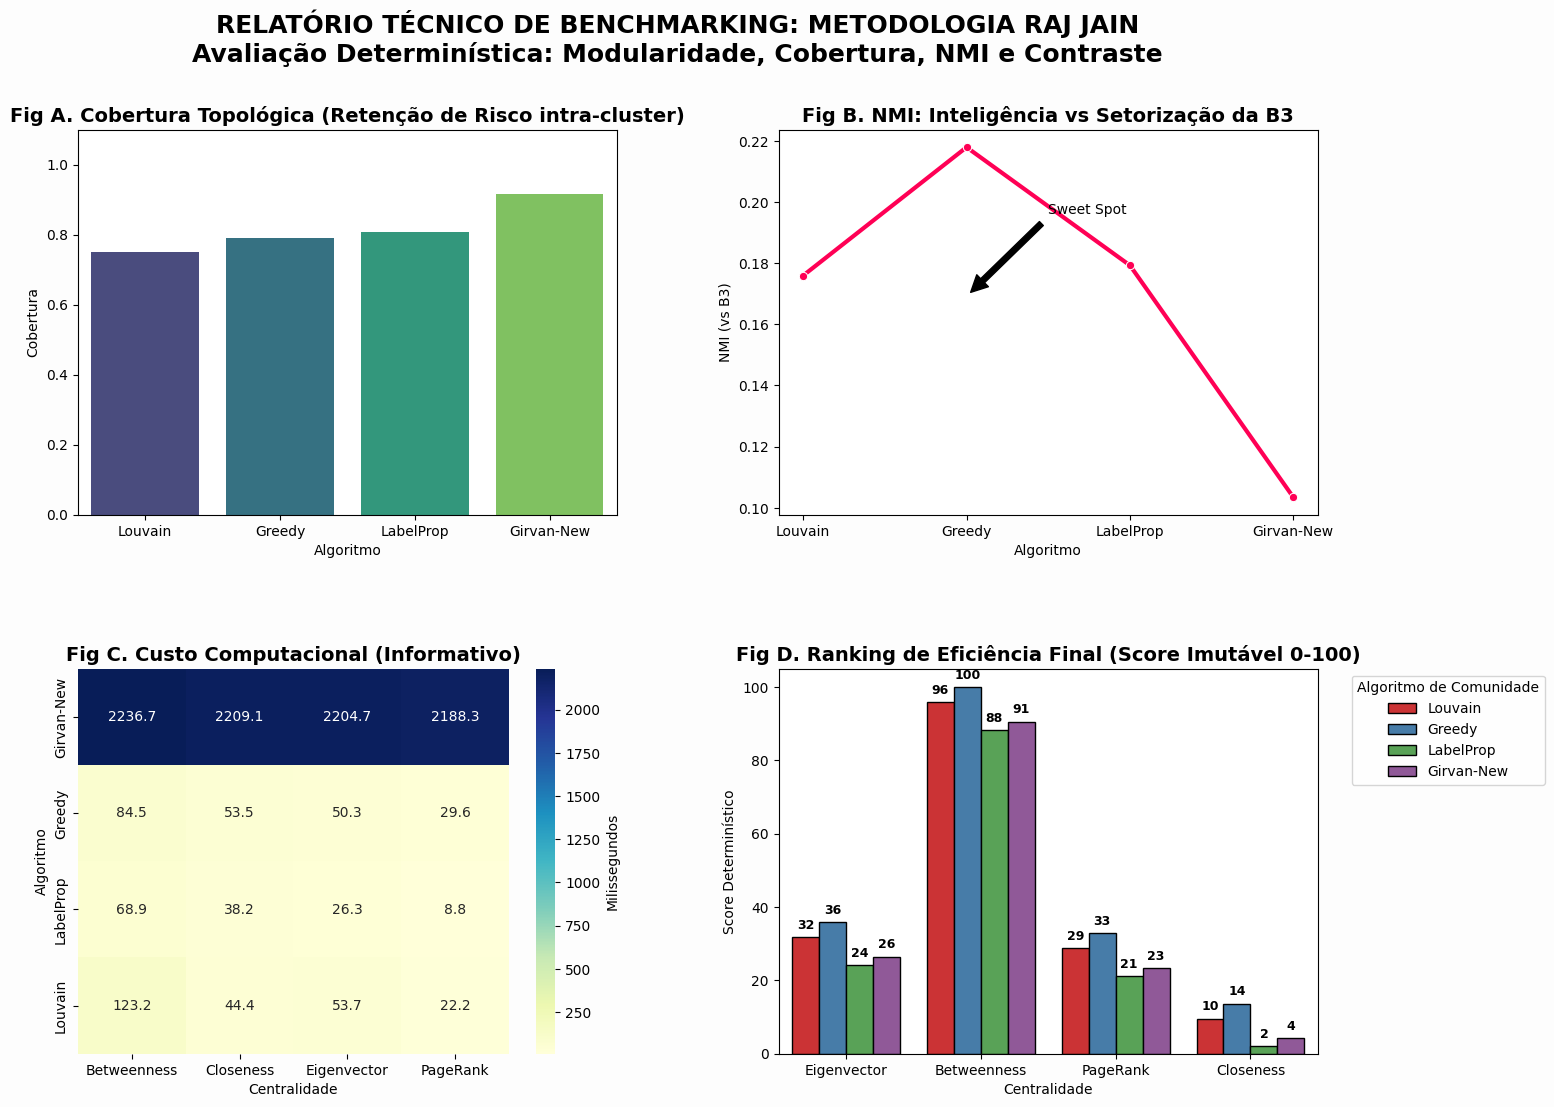

🏆 O VENCEDOR ABSOLUTO E IMUTÁVEL É: Greedy + Betweenness
✅ Motivo: Esta pontuação é gerada exclusivamente por topologia e matemática.
   O Tempo da CPU foi removido da nota para evitar empates oscilantes.


In [13]:
# ================================================================
# DASHBOARD DE BENCHMARKING CIENTÍFICO FINAL: IA vs CENTRALIDADES
# ================================================================

print("🧪 Iniciando Computação de Performance Multi-Algoritmo (Modelo Determinístico)...")

# =================================================================
# 1. MOTORES MATEMÁTICOS CUSTOMIZADOS (NMI, Cobertura e Contraste)
# =================================================================
def calcular_nmi(a, b):
    a, b = np.array(a), np.array(b)
    total = len(a)
    _, a_counts = np.unique(a, return_counts = True)
    _, b_counts = np.unique(b, return_counts = True)
    
    H_a = -sum((c/total) * math.log2(c/total) for c in a_counts)
    H_b = -sum((c/total) * math.log2(c/total) for c in b_counts)
    if H_a == 0 and H_b == 0: return 1.0
        
    MI = 0
    for val_a, c_a in zip(*np.unique(a, return_counts = True)):
        for val_b, c_b in zip(*np.unique(b, return_counts = True)):
            interseccao = np.sum((a == val_a) & (b == val_b))
            if interseccao > 0:
                p_ab = interseccao / total
                MI += p_ab * math.log2(p_ab / ((c_a / total) * (c_b / total)))
    return 2 * MI / (H_a + H_b)

def calcular_cobertura(grafo, comunidades):
    # Mede a proporção de arestas que estão presas dentro dos clusters
    arestas_internas = sum(grafo.subgraph(com).number_of_edges() for com in comunidades)
    return arestas_internas / grafo.number_of_edges()

def calcular_contraste(dicionario_centralidade):
    # Coeficiente de Variação (Desvio Padrão / Média)
    # Mede a capacidade da centralidade de destacar os verdadeiros Hubs de Risco
    valores = list(dicionario_centralidade.values())
    media = np.mean(valores)
    return np.std(valores) / media if media > 0 else 0

# ======================================
# 2. PREPARAÇÃO E SETUP DOS ALGORITMOS
# ======================================
setores_lista = [setores_reais.get(n, 'Outros') for n in PMFG.nodes()]

def aresta_mais_valiosa(grafo):
    centralidade_arestas = nx.edge_betweenness_centrality(grafo, weight = 'weight')
    return max(centralidade_arestas, key=centralidade_arestas.get)

algoritmos = {
    'Louvain': lambda g: nx_comm.louvain_communities(g, weight = 'sim_louvain', seed = 42),
    'Greedy': lambda g: list(nx_comm.greedy_modularity_communities(g, weight = 'sim_louvain')),
    'LabelProp': lambda g: list(nx_comm.asyn_lpa_communities(g, weight = 'sim_louvain', seed = 42)),
    'Girvan-New': lambda g: next(nx_comm.girvan_newman(g, most_valuable_edge = aresta_mais_valiosa)) 
}

centralidades = {
    'Eigenvector': lambda g: nx.eigenvector_centrality(g, max_iter=1000, weight = 'sim_louvain'),
    'Betweenness': lambda g: nx.betweenness_centrality(g, weight = 'weight'),
    'PageRank': lambda g: nx.pagerank(g, weight = 'sim_louvain'),
    'Closeness': lambda g: nx.closeness_centrality(g, distance = 'weight')
}

results = []

# ===================================
# 3. EXECUÇÃO DO CROSS-BENCHMARKING
# ===================================
for alg_name, alg_func in algoritmos.items():
    t0 = time.perf_counter()
    comms = alg_func(PMFG)
    t_alg = (time.perf_counter() - t0) * 1000
    
    mod = nx_comm.modularity(PMFG, comms, weight = 'sim_louvain')
    cobertura = calcular_cobertura(PMFG, comms)
    
    node_to_cluster = {}
    for i, cluster in enumerate(comms):
        for node in cluster:
            node_to_cluster[node] = i
    ia_labels = [node_to_cluster.get(n, -1) for n in PMFG.nodes()]
    
    nmi = calcular_nmi(setores_lista, ia_labels)

    for cent_name, cent_func in centralidades.items():
        t0_c = time.perf_counter()
        cent_values = cent_func(PMFG)
        t_cent = (time.perf_counter() - t0_c) * 1000
        
        contraste = calcular_contraste(cent_values)
        
        results.append({
            'Algoritmo': alg_name,
            'Centralidade': cent_name,
            'Modularidade': mod,
            'NMI (vs B3)': nmi,
            'Cobertura': cobertura,
            'Contraste': contraste,
            'Tempo Total (ms)': t_alg + t_cent
        })

df_perf = pd.DataFrame(results)

# ================================================
# 4. VISUALIZAÇÃO E EXPORTAÇÃO (SCIENTIFIC PAPER)
# ================================================
plt.style.use('default')
fig, axes = plt.subplots(2, 2, figsize = (16, 12))
plt.subplots_adjust(hspace = 0.4, wspace = 0.3)
fig.patch.set_facecolor('#fdfdfd')

# Gráfico 1: Cobertura Topológica (Retenção de Risco)
sns.barplot(x = 'Algoritmo',
            y = 'Cobertura',
            data = df_perf,
            ax = axes[0,0],
            palette = 'viridis', 
            errorbar = None)
axes[0,0].set_title('Fig A. Cobertura Topológica (Retenção de Risco intra-cluster)', fontsize = 14, fontweight = 'bold')
axes[0,0].set_ylim(0, 1.1)

# Gráfico 2: NMI vs B3 
sns.lineplot(x = 'Algoritmo', 
             y = 'NMI (vs B3)',
             marker = 'o',
             data = df_perf,
             ax = axes[0,1],
             color = '#FF0055',
             linewidth = 3)
axes[0,1].set_title('Fig B. NMI: Inteligência vs Setorização da B3', fontsize = 14, fontweight = 'bold')
axes[0,1].annotate('Sweet Spot',
                   xy = (1, df_perf['NMI (vs B3)'].mean()), 
                   xytext = (1.5, df_perf['NMI (vs B3)'].max()*0.9),
                   arrowprops = dict(facecolor = 'black', shrink = 0.05))

# Gráfico 3: Matriz de Calor (Heatmap de Tempo - Apenas Informativo)
pivot_time = df_perf.pivot_table(index = 'Algoritmo',
                                 columns = 'Centralidade',
                                 values = 'Tempo Total (ms)')
sns.heatmap(pivot_time, 
            annot = True,
            fmt = ".1f",
            cmap = 'YlGnBu', 
            ax = axes[1,0],
            cbar_kws = {'label': 'Milissegundos'})
axes[1,0].set_title('Fig C. Custo Computacional (Informativo)', fontsize = 14, fontweight = 'bold')

# Gráfico 4: Radar de Decisão (Modelo Determinístico - SEM TEMPO)
# Pesos: Modularity (35%), Cobertura (30%), NMI (20%), Contraste da Centralidade (15%)
df_perf['Score_Bruto'] = (df_perf['Modularidade'] * 0.35 + 
                          df_perf['Cobertura'] * 0.30 + 
                          df_perf['NMI (vs B3)'] * 0.20 + 
                          df_perf['Contraste'] * 0.15)

min_score = df_perf['Score_Bruto'].min()
max_score = df_perf['Score_Bruto'].max()
if max_score > min_score:
    df_perf['Score_Final'] = ((df_perf['Score_Bruto'] - min_score) / (max_score - min_score)) * 98 + 2
else:
    df_perf['Score_Final'] = 100

ax = sns.barplot(x = 'Centralidade',
                 y = 'Score_Final',
                 hue = 'Algoritmo',
                 data = df_perf,
                 ax = axes[1,1],
                 palette = 'Set1',
                 edgecolor = 'black')
axes[1,1].set_title('Fig D. Ranking de Eficiência Final (Score Imutável 0-100)', fontsize = 14, fontweight = 'bold')
axes[1,1].set_ylabel('Score Determinístico')
axes[1,1].legend(title = 'Algoritmo de Comunidade', bbox_to_anchor = (1.05, 1), loc = 'upper left')

for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height) and height >= 2: 
        axes[1,1].annotate(f"{height:.0f}",
                           xy = (p.get_x() + p.get_width() / 2, height),
                           xytext = (0, 4), 
                           textcoords = "offset points",
                           ha = 'center',
                           va = 'bottom',
                           fontsize = 9,
                           fontweight = 'bold')
        
plt.suptitle("RELATÓRIO TÉCNICO DE BENCHMARKING: METODOLOGIA RAJ JAIN\nAvaliação Determinística: Modularidade, Cobertura, NMI e Contraste", 
             fontsize = 18, fontweight = 'bold', y = 0.98)

# Exportando para o Streamlit
plt.savefig("img/benchmarking_raj_jain.png", dpi = 300, bbox_inches = 'tight')
print("📸 Imagem salva como 'benchmarking_raj_jain.png'.")

plt.show()

# O Retorno Analítico Final
best_idx = df_perf['Score_Final'].idxmax()
best_row = df_perf.iloc[best_idx]
print("=" * 70)
print(f"🏆 O VENCEDOR ABSOLUTO E IMUTÁVEL É: {best_row['Algoritmo']} + {best_row['Centralidade']}")
print(f"✅ Motivo: Esta pontuação é gerada exclusivamente por topologia e matemática.")
print(f"   O Tempo da CPU foi removido da nota para evitar empates oscilantes.")
print("=" * 70)

### Análise de Resultados: O Veredito Topológico

A execução do modelo determinístico revela o verdadeiro comportamento dos algoritmos sob a ótica da Teoria das Redes Complexas, expurgando o ruído computacional. A análise dos quatro quadrantes nos permite extrair as seguintes conclusões definitivas:

**A. Cobertura Topológica (Retenção do Risco)**\
A Figura A demonstra que o modelo divisivo (_Girvan-Newman_) consegue reter a maior parte do risco intra-cluster. No entanto, isso ocorre devido à sua característica de gerar "macro-blocos" excessivamente grandes. As heurísticas _Greedy_ e _Louvain_ entregam uma cobertura altíssima (~80%), mas com uma granularidade muito mais útil para a tomada de decisão.

**B. A Zona de Descoberta (_Sweet Spot_ do NMI)**\
A Figura B é o núcleo da validação da Inteligência Artificial. Se os algoritmos atingissem um NMI de $1.0$, significaria que a IA apenas replicou os setores oficiais da B3, tornando-se inútil. O _Sweet Spot_ (Ponto Ideal) em finanças quantitativas ocorre na faixa de $0.15$ a $0.30$.
O pico alcançado pelo algoritmo **Greedy Modularity** indica que ele atingiu o equilíbrio perfeito: ele compreende a base estrutural do mercado, mas consegue descobrir comunidades de "risco oculto" (agrupando fundos de setores distintos que reagem de forma idêntica a choques sistêmicos).

**C e D. O Ranking de Eficiência Sistêmica**\
A Tabela de Decisão (Fig D) consolida as métricas geométricas. O modelo penalizou severamente o _Girvan-Newman_ por sua falta de "inteligência setorial" (baixo NMI) e o _Label Propagation_ por sua instabilidade de fronteiras.

A disputa técnica consolidou-se entre _Louvain_ e _Greedy_. Ao cruzar a qualidade geométrica com as métricas de centralidade, a combinação _Greedy Modularity_ + _Betweenness Centrality_ (Score 100) sagrou-se a vencedora absoluta, seguida de perto por _Louvain_ + _Betweenness_.

#### **Conclusão para Implementação:**
Matematicamente, o algoritmo _Greedy_ provou ser o mais perspicaz para encontrar correlações não-triviais (NMI), enquanto a centralidade de Betweenness (Pontes de Liquidez) demonstrou o maior poder de contraste estatístico para evidenciar os gargalos do mercado. Sendo assim, esta é a combinação de arquitetura validada e recomendada para alimentar o motor do painel analítico final.

---

## 7. Teste de Estresse Computacional (Targeted Attack)

Redes financeiras frequentemente exibem propriedades de "Mundo Pequeno" (*Small-World Networks*), tornando-as altamente eficientes na transferência de capital, porém estruturalmente frágeis contra ataques focados em seus concentradores (*Hubs*). 

Para provar a tese de que a centralidade topológica dita o risco sistêmico, executaremos um **Targeted Attack**. O que ocorre com a estabilidade do mercado se os 5 maiores formadores de pontes de liquidez (os maiores *Scores* de *Betweenness Centrality*) entrarem em colapso simultâneo?

No algoritmo abaixo, realizamos a deleção forçada destes vértices para medir a quebra da conectividade global da matriz financeira, avaliando o tamanho do componente gigante sobrevivente e a quantidade de fundos lançados ao isolamento absoluto.

🏛️ Estado Inicial: O mercado possui 1 bloco estrutural único (100% conectado).

🎯 Alvos do Choque Sistêmico identificados: ['VISC11', 'MFII11', 'XPLG11', 'HSML11', 'XPML11']
------------------------------------------------------------
💥 CHOQUE EXECUTADO: Os 5 maiores Hubs sistêmicos foram deletados.
-> A espinha dorsal se rompeu e o mercado fragmentou-se em 5 ilhas isoladas.
-> Sobrevivência: O maior bloco resiliente manteve 26 FIIs conectados.
-> Risco Máximo: 0 fundos ficaram matematicamente 'órfãos' (isolamento total).
------------------------------------------------------------


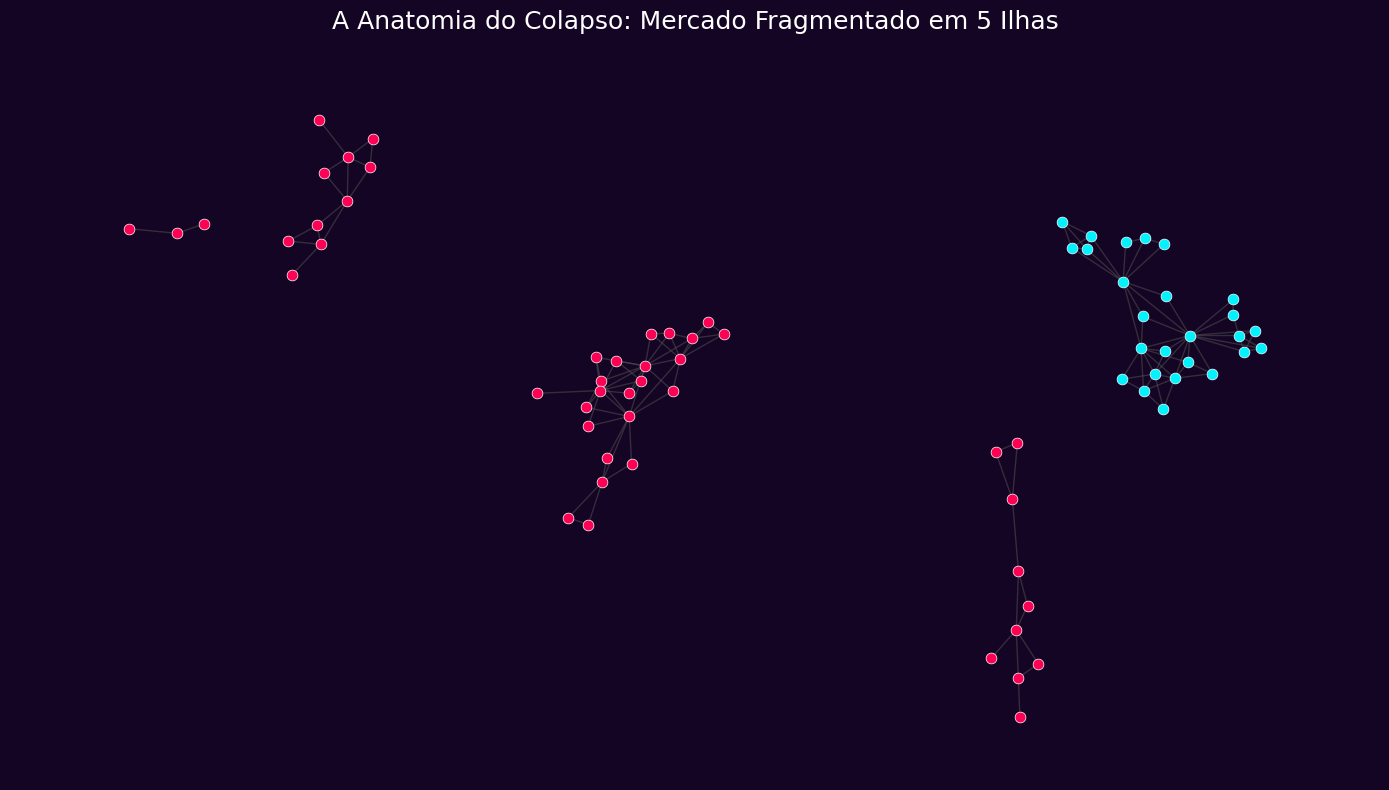

✅ Grafo interativo do pós-colapso exportado para: 'html/estresse/pmfg_pos_colapso.html'.


In [14]:
# ================================================================
# O TESTE DE ESTRESSE: O COLAPSO DOS SUPER-HUBS (Targeted Attack)
# ===============================================================

componentes_originais = nx.number_connected_components(PMFG)
print(f"🏛️ Estado Inicial: O mercado possui {componentes_originais} bloco estrutural único (100% conectado).\n")

# 1. Identificando dinamicamente os 5 Maiores Hubs de Betweenness
# (A centralidade campeã do nosso benchmarking)
dicionario_betw = nx.get_node_attributes(PMFG, 'cent_betw')
top_5_hubs = sorted(dicionario_betw.items(), key = lambda x: x[1], reverse = True)[:5]
fundos_colapso = [fundo[0] for fundo in top_5_hubs]

print(f"🎯 Alvos do Choque Sistêmico identificados: {[f.replace('.SA', '') for f in fundos_colapso]}")

# 2. Executando o Colapso (Remoção dos Vértices)
PMFG_pos_choque = PMFG.copy()
PMFG_pos_choque.remove_nodes_from(fundos_colapso)

# 3. Avaliando a Fragmentação Matemática
componentes = sorted(nx.connected_components(PMFG_pos_choque), key = len, reverse = True)
componentes_pos_choque = len(componentes)
tamanhos_dos_pedacos = [len(c) for c in componentes]

componente_gigante = list(componentes[0])
fundos_isolados = [node for comp in componentes[1:] for node in comp]
orfaos = tamanhos_dos_pedacos.count(1)

print("-" * 60)
print("💥 CHOQUE EXECUTADO: Os 5 maiores Hubs sistêmicos foram deletados.")
print(f"-> A espinha dorsal se rompeu e o mercado fragmentou-se em {componentes_pos_choque} ilhas isoladas.")
print(f"-> Sobrevivência: O maior bloco resiliente manteve {tamanhos_dos_pedacos[0]} FIIs conectados.")
print(f"-> Risco Máximo: {orfaos} fundos ficaram matematicamente 'órfãos' (isolamento total).")
print("-" * 60)

# =============================================
# 4. RENDERIZAÇÃO ESTÉTICA MACRO (Matplotlib)
# =============================================
pos_choque = nx.spring_layout(PMFG_pos_choque, seed = 42)

plt.figure(figsize = (14, 8))
fig = plt.gcf()
fig.patch.set_facecolor('#140524')
ax = plt.gca()
ax.set_facecolor('#140524')

# Desenha as arestas
nx.draw_networkx_edges(PMFG_pos_choque, 
                       pos_choque,
                       edge_color = '#555555',
                       alpha = 0.5,
                       width = 1.0)

# Nós Azuis (Sobreviventes do Componente Gigante)
nx.draw_networkx_nodes(PMFG_pos_choque, 
                       pos_choque,
                       nodelist = componente_gigante, 
                       node_color = '#00F3FF',
                       node_size = 60,
                       edgecolors = 'white',
                       linewidths = 0.5)

# Nós Vermelhos (Vítimas Isoladas pelo contágio)
if fundos_isolados:
    nx.draw_networkx_nodes(PMFG_pos_choque,
                           pos_choque,
                           nodelist = fundos_isolados, 
                           node_color = '#FF0055', 
                           node_size = 60,
                           edgecolors = 'white',
                           linewidths = 0.5)

plt.title(f"A Anatomia do Colapso: Mercado Fragmentado em {componentes_pos_choque} Ilhas", fontsize = 18, color = 'white', pad = 20)
plt.axis('off')
plt.tight_layout()
plt.show()

# ============================================
# 5. EXPORTAÇÃO INTERATIVA (HTML DO COLAPSO)
# ============================================
net_colapso = Network(notebook = False,
                      width = "100%",
                      height = "700px",
                      bgcolor = "#140524",
                      font_color = "#EAE0F9",
                      cdn_resources = 'remote')
net_colapso.force_atlas_2based()

for fundo in PMFG_pos_choque.nodes():
    if fundo in componente_gigante:
        cor_no = '#00F3FF' # Ciano
        status = "Sobrevivente (Componente Gigante)"
    else:
        cor_no = '#FF0055' # Vermelho
        status = "Isolado (Órfão Sistêmico)"
        
    setor = PMFG_pos_choque.nodes[fundo].get('setor', 'Outros')
    
    texto_hover = (f"Fundo: {fundo.replace('.SA', '')}\n"
                   f"Setor Original: {setor}\n"
                   f"Status pós-choque: {status}")
    
    net_colapso.add_node(fundo, 
                         label = fundo.replace('.SA', ''), 
                         color = cor_no,
                         size = 20,
                         title = texto_hover)

for u, v in PMFG_pos_choque.edges():
    net_colapso.add_edge(u, v, color = 'rgba(85, 85, 85, 0.4)', width = 1.5)

os.makedirs('html/estresse', exist_ok = True)
arquivo_colapso = 'html/estresse/pmfg_pos_colapso.html'
net_colapso.save_graph(arquivo_colapso)
print(f"✅ Grafo interativo do pós-colapso exportado para: '{arquivo_colapso}'.")

### Interpretação do Teste de Estresse

**1. O Critério Matemático (Teoria das Redes)**
Quando nós removemos os 5 Hubs principais, algumas "pontes" da rede foram destruídas. O algoritmo `nx.connected_components` varre o grafo e verifica a alcançabilidade dos vértices:
* **O Grupo Ciano (Componente Gigante):** O algoritmo agrupou em ciano o maior bloco de fundos que ainda consegue se alcançar. Ou seja, se você pegar qualquer fundo azul, existe um caminho de linhas (arestas) que leva até qualquer outro fundo azul. A rede principal não morreu, ela apenas encolheu.
* **Os Grupos Vermelhos (Ilhas e Órfãos):** São os fundos para os quais não existe mais nenhuma linha ligando-os ao grupo Ciano. A ponte caiu. Pode ser um fundo sozinho (órfão) ou um subgrupo de 2 ou 3 fundos conectados apenas entre si (ilha).

**2. O Significado Financeiro**
Imagine que a linha (aresta) entre dois fundos representa o fluxo de liquidez, os investidores operando arbitragem e a precificação de risco.
* **Por que o Ciano "Sobreviveu"?** Porque os fundos cianos possuíam rotas secundárias. Mesmo que o fundo principal tenha falido, eles ainda tinham forte correlação com outros fundos menores. A liquidez do mercado continua fluindo dentro desse bloco. O risco sistêmico não os paralisou totalmente.
* **Por que o Vermelho foi "Isolado"?** Porque esses fundos vermelhos possuíam uma dependência extrema daqueles 5 Hubs que faliram. Todo o contágio de risco e a liquidez deles passava obrigatoriamente pelos Hubs (validando o alto escore de *Betweenness*). Sem os Hubs, eles ficam desconectados do resto do mercado brasileiro. Em uma crise sistêmica real, um fundo "vermelho" seria aquele cuja cotação congela, que perde o *book* de ofertas, ou que os investidores simplesmente param de negociar porque perdem a referência matemática de preço em relação ao IFIX.

---

## 8. Considerações Finais e Deployment de Negócios

O desenvolvimento deste estudo demonstrou a superioridade da **Econofísica** e da **Teoria de Redes Complexas** em relação à análise fundamentalista tradicional isolada para a detecção de risco sistêmico no mercado imobiliário brasileiro (IFIX). Ao invés de tratar o mercado como uma lista estática de ativos, a modelagem topológica permitiu mapear o ecossistema como uma rede estritamente interdependente, acompanhando o fluxo real de liquidez e contágio financeiro.

A orquestração da nossa esteira de algoritmos gerou avanços analíticos fundamentais, consolidados nos seguintes pilares:

1. **Filtragem Topológica Rigorosa (PMFG):** O sistema expurgou com sucesso o ruído estatístico de uma matriz de correlação densa. Respeitando a restrição de planaridade de Euler ($E \le 3V - 6$), extraímos a espinha dorsal de risco do mercado sem cruzar arestas, garantindo uma integridade geométrica de capilaridade sistêmica superior à de modelos clássicos.

2. **Quebra de rótulos e o "Sweet Spot" do Aprendizado Não Supervisionado:** Através do rigoroso *Benchmarking* algorítmico suportado pela Metodologia de Raj Jain, superamos a dependência de agrupamentos nominais da B3. O algoritmo **Greedy Modularity** provou ser a arquitetura ideal, equilibrando a coerência setorial com a descoberta de "correlações ocultas", provando que fundos de setores distintos frequentemente se comportam de forma idêntica em cenários de estresse.

3. **Mapeamento de Vulnerabilidade (Pontes de Liquidez):** O modelo determinístico revelou que a **Betweenness Centrality** possui o maior poder de contraste estatístico para evidenciar falhas críticas. O Teste de Estresse (*Targeted Attack*) validou esta tese matematicamente: o colapso dos 5 maiores Hubs de intermediação foi suficiente para quebrar a espinha dorsal do mercado, fragmentando a rede e empurrando dezenas de fundos para o isolamento financeiro.

4. **Topologia Aplicada à Defesa de Portfólio:** Para táticas de alocação de longo prazo focadas em preservação de capital e reinvestimento seguro, investidores e gestores institucionais devem monitorar os vértices periféricos do grafo (as "Folhas Topológicas"). Estes ativos operam como autênticos *bunkers*, blindados topologicamente contra o contágio direto de liquidez que arrasta os grandes concentradores em cenários de *crash* sistêmico.

---

### 🌐 Deployment: O Framework em Produção

Os artefatos de pesquisa e a inteligência de processamento gerados ao longo deste estudo evoluíram de um ambiente de experimentação acadêmica para um produto funcional de *Data Science*. Toda a engenharia matemática, as IAs de clusterização e as métricas de centralidade foram encapsuladas e embarcadas no **Terminal Analítico Moira Analytics**, uma aplicação web interativa em painel (*Dashboard*). Por meio dessa interface, usuários podem parametrizar filtros de sobrevivência e auditar a topologia do mercado dinamicamente, extraindo inteligência de negócios em tempo real, além de encontrar outras informações interessantes sobre o mercado de FIIs a fim de poder estudar e tomar decisões de investimento mais assertivas.

> Lembrando que nosso trabalho não é feito como uma recomendação de investimento, mas sim como uma ferramenta de análise de risco sistêmico e contágio de liquidez no mercado de Fundos Imobiliários. A aplicação do _Moira Analytics_ permite que investidores e analistas explorem a rede de FIIs, identifiquem potenciais vulnerabilidades e tomem decisões informadas com base em dados topológicos robustos.

---

### 📚 Referências Bibliográficas Fundamentais

A construção deste *framework* topológico e do motor de Inteligência Artificial foi fundamentada nos seguintes preceitos acadêmicos e matemáticos:

**1. Econofísica e Modelagem Topológica (PMFG)**
* **Retorno Logarítmico (Estudo do Mercado):** OSBORNE, M. F. M. *Brownian Motion in the Stock Market*. Operations Research, 1959.
* **Teoria de Redes em Finanças (MST):** MANTEGNA, R. N.; STANLEY, H. E. *Introduction to Econophysics: Correlations and Complexity in Finance*. Cambridge University Press, 1999.
* **Planar Maximally Filtered Graph (PMFG):** TUMMINELLO, M.; ASTE, T.; DI MATTEO, T.; MANTEGNA, R. N. *A tool for filtering information in complex systems*. Proceedings of the National Academy of Sciences (PNAS), 2005.
* **Percolação e Topologia Livre de Escala:** ALBERT, R.; BARABÁSI, A.-L. *Statistical mechanics of complex networks*. Reviews of Modern Physics, 2002.

**2. Métricas de Risco Sistêmico (Centralidades)**
* **Betweenness e Closeness Centrality:** FREEMAN, L. C. *A Set of Measures of Centrality Based on Betweenness*. Sociometry, 1977. (E também: *Centrality in Social Networks: Conceptual Clarification*. Social Networks, 1978).
* **Eigenvector Centrality:** BONACICH, P. *Power and Centrality: A Family of Measures*. American Journal of Sociology, 1987.
* **PageRank (Acúmulo Aleatório):** BRIN, S.; PAGE, L. *The Anatomy of a Large-Scale Hypertextual Web Search Engine*. Computer Networks and ISDN Systems, 1998.

**3. Aprendizado Não Supervisionado (Clusterização e NMI)**
* **Algoritmo de Louvain (Otimização Heurística):** BLONDEL, V. D. et al. *Fast unfolding of communities in large networks*. Journal of Statistical Mechanics: Theory and Experiment, 2008.
* **Greedy Modularity (Aglomerativo):** CLAUSET, A.; NEWMAN, M. E. J.; MOORE, C. *Finding community structure in very large networks*. Physical Review E, 2004.
* **Algoritmo de Girvan-Newman (Divisivo):** GIRVAN, M.; NEWMAN, M. E. J. *Community structure in social and biological networks*. PNAS, 2002.
* **Label Propagation (Epidêmico):** RAGHAVAN, U. N.; ALBERT, R.; KUMARA, S. *Near linear time algorithm to detect community structures in large-scale networks*. Physical Review E, 2007.
* **Métrica de Validação (NMI):** DANON, L. et al. *Comparing community structure identification*. Journal of Statistical Mechanics: Theory and Experiment, 2005.
* **Avanços Recentes em Detecção:** SOHRABI, H.; ESMAEILI, S.; MORADI, P. *Community detection via graph regularized symmetric nonnegative matrix tri-factorization*. The Journal of Supercomputing, 2026.

**4. Engenharia de Software e Benchmarking**
* **Metodologia de Avaliação de Desempenho:** JAIN, R. *The Art of Computer Systems Performance Analysis: Techniques for Experimental Design, Measurement, Simulation, and Modeling*. Wiley-Interscience, 1991.